# Visualization of saved distance matrices


Visualize arrays saved in `/res/sim_res` folder here.

TODO: Implement a SIS model

TODO: Do this in ELFI.


In [1]:
import os
os.getcwd()

os.chdir('/u/50/ojalaf2/unix/Dropbox (Aalto)/Ecoli/')

import importlib
import numpy as np
import matplotlib.pyplot as plt

from grid.grid_functions import *
from cluster.scripts.BSI_functions import *

incidence = True # If true, use incidence data instead of proportions.

print(os.getcwd())

from cluster.scripts.load_data import *

Current working directory: /u/50/ojalaf2/unix/Dropbox (Aalto)/Ecoli
/u/50/ojalaf2/unix/Dropbox (Aalto)/Ecoli


In [2]:
import grid_functions
importlib.reload(grid_functions)
from grid_functions import *


In [7]:
250*250

62500

Results to visualize: res/sim_res/obs_NORM_A_I0_2023-09-08_14-43-58/sim_params.txt
Year
2004    3.895481e-06
2005    3.949891e-10
2006    1.263574e-05
2007    4.214390e-06
2008    1.053623e-05
2009    5.791327e-06
2010    1.535184e-05
2011    8.640565e-06
2012    2.363202e-05
2013    3.185117e-05
2014    3.004447e-05
2015    1.012509e-05
2016    2.025119e-05
2017    2.130096e-05
Name: A, dtype: float64


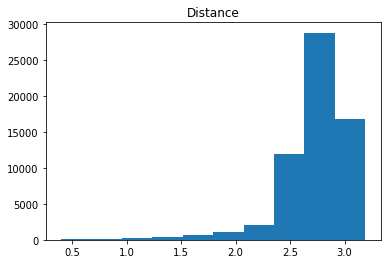

Beta mean: 0.02239747807577985
Gamma mean: 0.0021178390182770217
R = mean(beta/gamma): 11.364694780936308
R = median(beta/gamma): 11.000727630522087


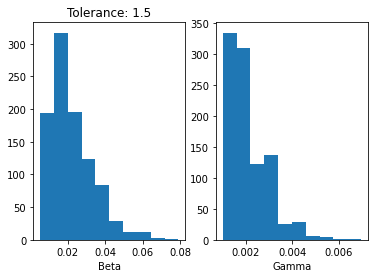

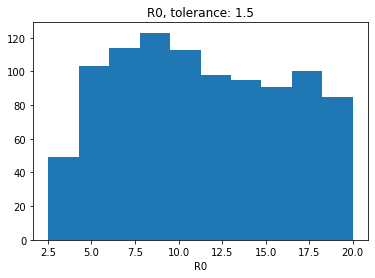

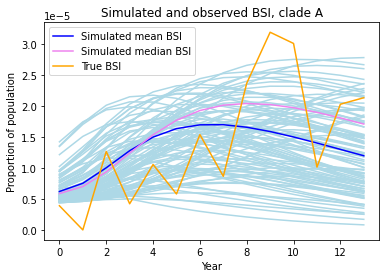

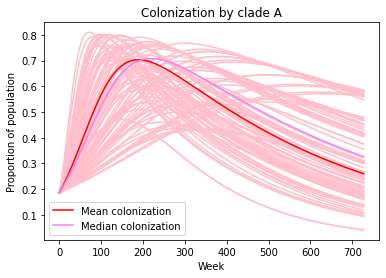

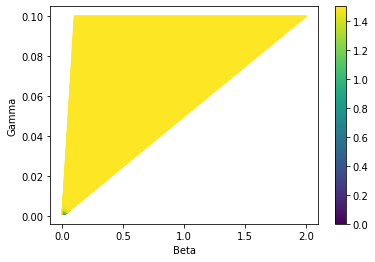

In [41]:
visualize_results("res/sim_res/obs_NORM_A_I0_2023-09-08_14-43-58", 1.5)

(62500, 2)


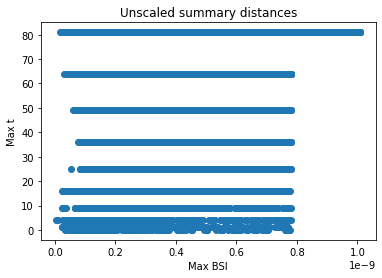

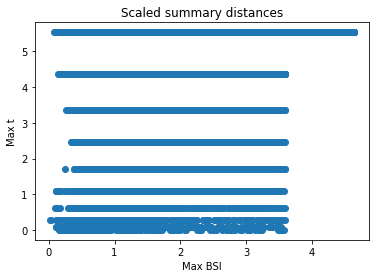

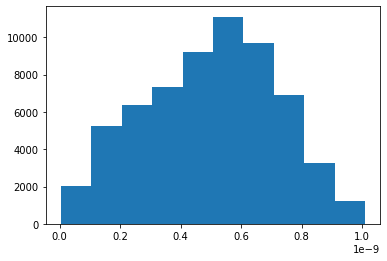

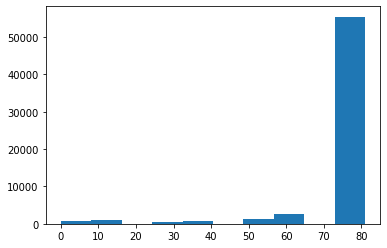

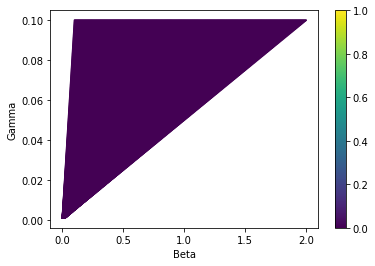

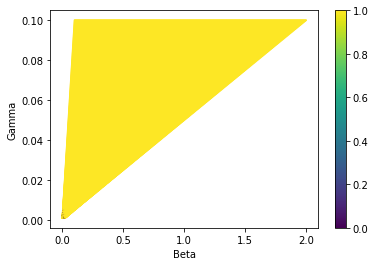

Max BSI, scaled


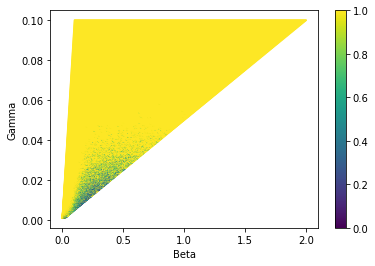

Max t, scaled


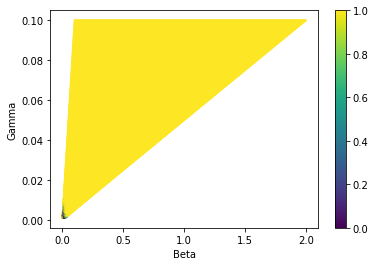

In [38]:
summary_dists = np.load("res/sim_res/obs_NORM_A_I0_2023-09-08_14-43-58/summary_dists.npy")
pairs = np.load("res/sim_res/obs_NORM_A_I0_2023-09-08_14-43-58/pairs.npy")
dists = np.load("res/sim_res/obs_NORM_A_I0_2023-09-08_14-43-58/dists.npy")
print(summary_dists.shape)

## Unscaled
plt.scatter(summary_dists[:,0], summary_dists[:,1])
plt.title("Unscaled summary distances")
plt.xlabel("Max BSI")
plt.ylabel("Max t") # Sus? Probably because weeks -> years after the observational model.
plt.show()

## Scaled:
plt.scatter(1/np.std(summary_dists[:,0])*summary_dists[:,0], 1/np.std(summary_dists[:,1])*summary_dists[:,1])
plt.title("Scaled summary distances")
plt.xlabel("Max BSI")
plt.ylabel("Max t") # Sus? Probably because weeks -> years after the observational model.
plt.show()

plt.hist(summary_dists[:,0])
plt.show()


plt.hist(summary_dists[:,1])
plt.show()



## Scatterplot:

# Max BSI, unscaled:
scatter_distance_points(pairs[:,0], pairs[:,1], summary_dists[:,0], true_beta = None, true_gamma = None, ylab = "Gamma", xlab = "Beta", cutoff_upper = 1, cutoff_lower = 0, save = False, filename = "no_name")

# Max t, unscaled:
scatter_distance_points(pairs[:,0], pairs[:,1], summary_dists[:,1], true_beta = None, true_gamma = None, ylab = "Gamma", xlab = "Beta", cutoff_upper = 1, cutoff_lower = 0, save = False, filename = "no_name")

## Scaled scatterplot:

print("Max BSI, scaled")
scatter_distance_points(pairs[:,0], pairs[:,1], 1/np.std(summary_dists[:,0])*summary_dists[:,0], true_beta = None, true_gamma = None, ylab = "Gamma", xlab = "Beta", cutoff_upper = 1, cutoff_lower = 0, save = False, filename = "no_name")

print("Max t, scaled")
scatter_distance_points(pairs[:,0], pairs[:,1], 1/np.std(summary_dists[:,1])*summary_dists[:,1], true_beta = None, true_gamma = None, ylab = "Gamma", xlab = "Beta", cutoff_upper = 1, cutoff_lower = 0, save = False, filename = "no_name")


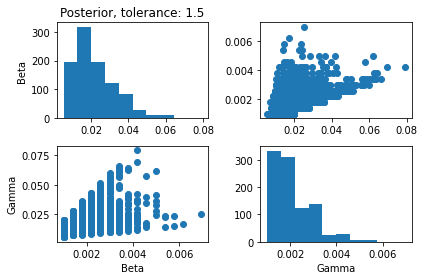

In [77]:
# Posterior scatterplot:
summary_dists = np.load("res/sim_res/obs_NORM_A_I0_2023-09-08_14-43-58/summary_dists.npy")
eps = 1.5
acc_pairs = pairs[np.where(dists< eps)[0],:]


fig, axs = plt.subplots(2, 2)
axs[0,0].hist(acc_pairs[:,0])
axs[0,0].set_ylabel("Beta")
axs[0,1].scatter(acc_pairs[:,0], acc_pairs[:,1])
#axs[0,1].set_ylabel("Beta")
#axs[0,1].set_xlabel("Gamma")
axs[1,0].scatter(acc_pairs[:,1], acc_pairs[:,0])
axs[1,0].set_ylabel("Gamma")
axs[1,0].set_xlabel("Beta")
axs[1,1].hist(acc_pairs[:,1])
axs[1,1].set_xlabel("Gamma")
axs[0,0].set_title(f"Posterior, tolerance: {eps}")
plt.tight_layout()
plt.show()

2.1751285672874054e-10
14.628654302710965
All simulations:


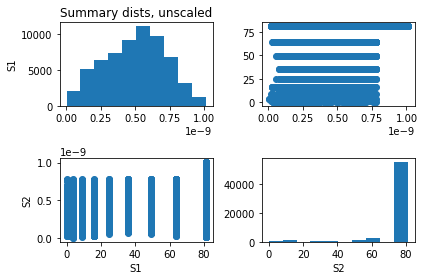

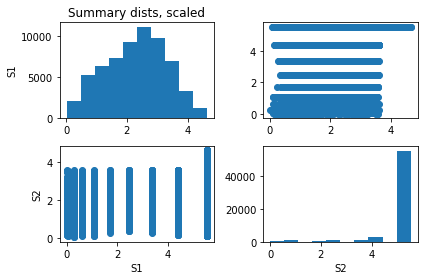

(62500, 2)
(971, 2)
Accepted simulations only (dists < eps):


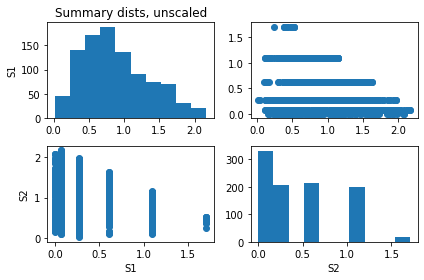

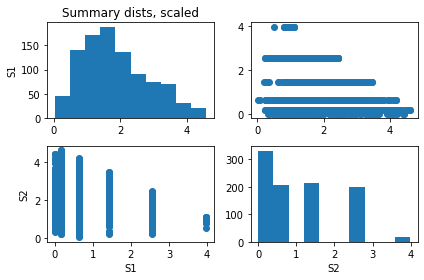

In [84]:
summary_dists = np.load("res/sim_res/obs_NORM_A_I0_2023-09-08_14-43-58/summary_dists.npy")
print(np.std(summary_dists[:,0]))

print(np.std(summary_dists[:,1]))
def plot_summary_dists(summary_dists, scale = False):
    # Plot histograms and scatterplots of summary dists
    # Assumes two summaries
    
    if scale:
        summary_dists[:,0] = 1/np.std(summary_dists[:,0])*summary_dists[:,0]
        summary_dists[:,1] = 1/np.std(summary_dists[:,1])*summary_dists[:,1]
        
    fig, axs = plt.subplots(2, 2)
    axs[0,0].hist(summary_dists[:,0])
    axs[0,0].set_ylabel("S1")
    axs[0,1].scatter(summary_dists[:,0], summary_dists[:,1])
    #axs[0,1].set_ylabel("Beta")
    #axs[0,1].set_xlabel("Gamma")
    axs[1,0].scatter(summary_dists[:,1], summary_dists[:,0])
    axs[1,0].set_ylabel("S2")
    axs[1,0].set_xlabel("S1")
    axs[1,1].hist(summary_dists[:,1])
    axs[1,1].set_xlabel("S2")
    if scale:
        axs[0,0].set_title(f"Summary dists, scaled")
    else:
        axs[0,0].set_title(f"Summary dists, unscaled")
    plt.tight_layout()
    plt.show()


print("All simulations:")
plot_summary_dists(summary_dists, scale = False)
plot_summary_dists(summary_dists, scale = True) # Note top right y-axis!


# Summary dists, accepted distances only:

indx = np.where(dists< eps)[0]
acc_summary_dists = summary_dists[indx,:]
print(summary_dists.shape)
print(acc_summary_dists.shape)

print("Accepted simulations only (dists < eps):")
# No difference??
plot_summary_dists(acc_summary_dists, scale = False)
plot_summary_dists(acc_summary_dists, scale = True) 

In [71]:
# Change theta_bsi quickly:
#R_bsi = 3176/5400000/14 # proportion of BSI cases per year in the entire population. NOTE: an average of the entire population when there is considerable differences between age groups (older population more likely to get BSI)
#theta_bsi = R_bsi/52 # proportion of BSI cases per week in the entire population
            
#modify_grid_params("grid/grid_params/wider prior", "theta_bsi", theta_bsi)

DirectoryError: grid/grid_params/final yearly bsi/.ipynb_checkpoints
DirectoryError: grid/grid_params/final yearly bsi/.ipynb_checkpoints


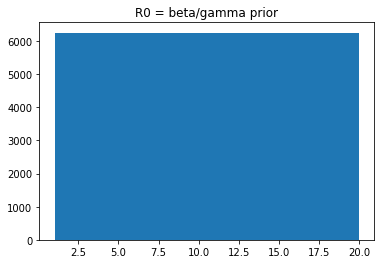

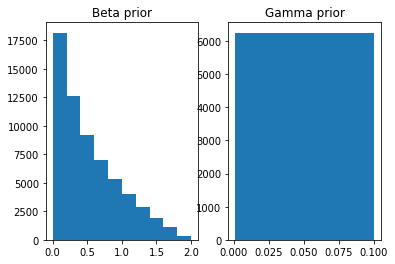

In [42]:
# How to visualize priors: 

plt.hist(pairs[:,0]/pairs[:,1])
plt.title("R0 = beta/gamma prior")
plt.savefig("res/sim_res/obs_NORM_A_I0_2023-09-08_14-43-58/R0_prior_hist.pdf", format="pdf", bbox_inches="tight")
plt.show()


fig, axs = plt.subplots(1, 2)
axs[0].hist(pairs[:,0])
axs[1].hist(pairs[:,1])
#axs[2].hist(pairs[:,0]/pairs[:,1])
axs[0].set_title(f"Beta prior")
axs[1].set_title(f"Gamma prior")
#axs[2].set_title(f"R0 prior")
plt.savefig("res/sim_res/obs_NORM_A_I0_2023-09-08_14-43-58/prior_hist.pdf", format="pdf", bbox_inches="tight")
plt.show()


Results to visualize: res/sim_res/time shift/theta bsi fix/obs_NORM_A_I0_2023-09-06_12-20-22/sim_params.txt
Year
2004    3.895481e-06
2005    3.949891e-10
2006    1.263574e-05
2007    4.214390e-06
2008    1.053623e-05
2009    5.791327e-06
2010    1.535184e-05
2011    8.640565e-06
2012    2.363202e-05
2013    3.185117e-05
2014    3.004447e-05
2015    1.012509e-05
2016    2.025119e-05
2017    2.130096e-05
Name: A, dtype: float64


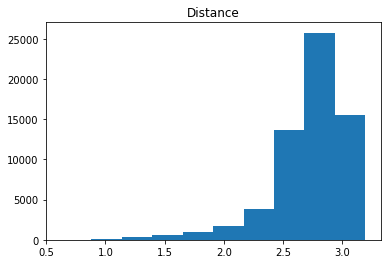

Beta mean: 0.015552196976409903
Gamma mean: 0.0024036879224213926
R = mean(beta/gamma): 6.625406018953865
R = median(beta/gamma): 6.763053975903615


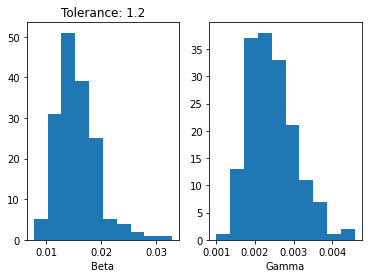

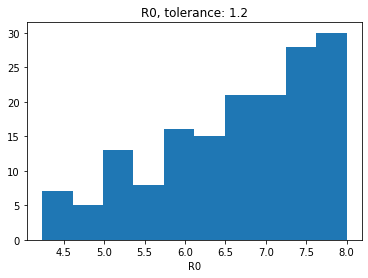

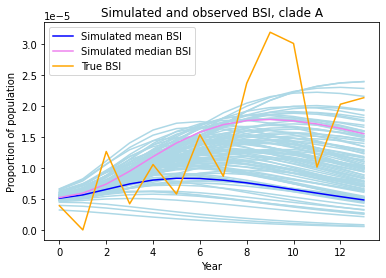

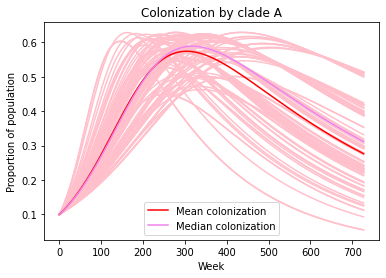

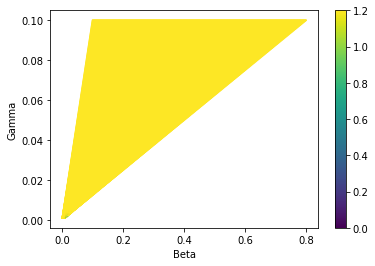

Results to visualize: res/sim_res/time shift/theta bsi fix/obs_NORM_A_no_I0_2023-09-06_12-47-18/sim_params.txt
Year
2004    3.895481e-06
2005    3.949891e-10
2006    1.263574e-05
2007    4.214390e-06
2008    1.053623e-05
2009    5.791327e-06
2010    1.535184e-05
2011    8.640565e-06
2012    2.363202e-05
2013    3.185117e-05
2014    3.004447e-05
2015    1.012509e-05
2016    2.025119e-05
2017    2.130096e-05
Name: A, dtype: float64


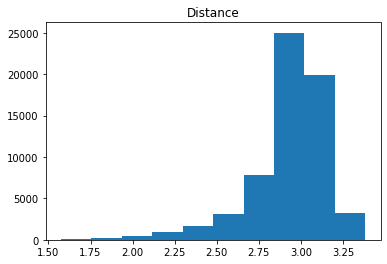

Beta mean: 0.043523915690073876
Gamma mean: 0.006431347009660263
R = mean(beta/gamma): 6.839286726364919
R = median(beta/gamma): 7.016065662650602


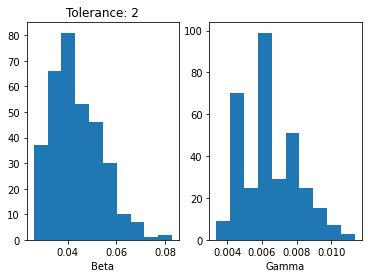

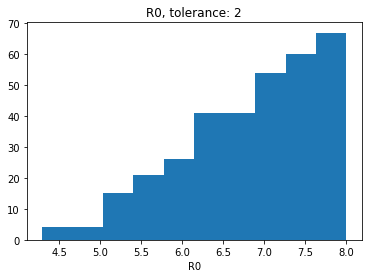

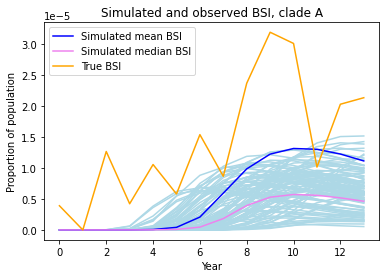

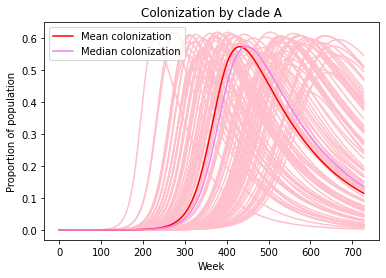

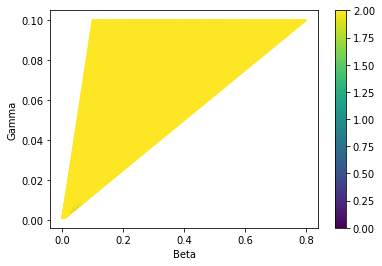

In [80]:
# NORM, clade A, no I0 fix

import grid_functions
importlib.reload(grid_functions)
from grid_functions import *

#visualize_results("res/sim_res/time shift/obs_NORM_A_I0_2023-09-05_12-38-21", 0.3)
visualize_results("res/sim_res/time shift/theta bsi fix/obs_NORM_A_I0_2023-09-06_12-20-22", 1.2)


#visualize_results("res/sim_res/time shift/obs_NORM_A_no_I0_2023-09-05_12-57-28", 0.3)
visualize_results("res/sim_res/time shift/theta bsi fix/obs_NORM_A_no_I0_2023-09-06_12-47-18", 2)



Results to visualize: res/sim_res/time shift/obs_NORM_C2_no_I0_2023-09-05_13-35-57/sim_params.txt
Year
2004    3.895481e-10
2005    3.949891e-10
2006    4.211914e-10
2007    8.428780e-06
2008    7.024155e-06
2009    8.686990e-06
2010    3.070367e-06
2011    5.760377e-06
2012    1.074183e-05
2013    2.123411e-05
2014    1.365658e-05
2015    2.531273e-05
2016    1.518839e-05
2017    1.656741e-05
Name: C2, dtype: float64


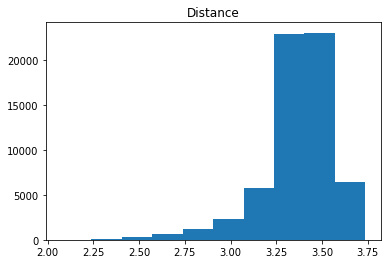

Beta mean: 0.03774079534386951
Gamma mean: 0.005688634723224696
R = mean(beta/gamma): 6.737273471212038
R = median(beta/gamma): 6.875503614457833


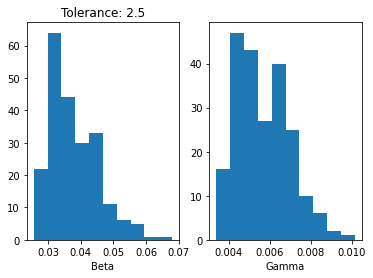

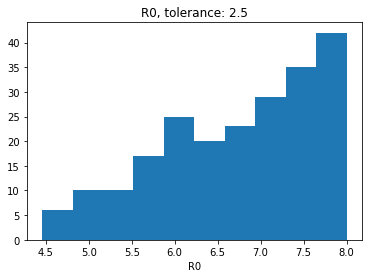

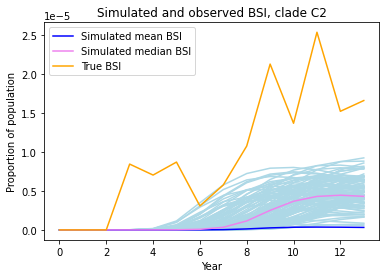

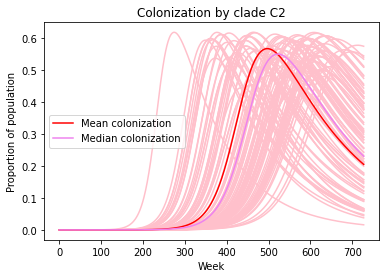

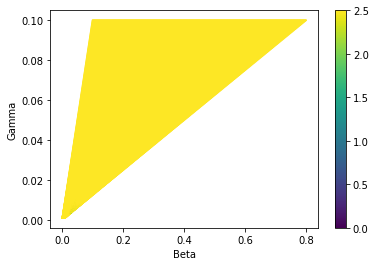

In [23]:
# NORM, clade C2, I0 fix

#visualize_results("res/sim_res/time shift/obs_NORM_C2_I0_2023-09-05_13-16-27", 2.6)



# NORM clade C2,no I0 fix (starts at 0)

visualize_results("res/sim_res/time shift/obs_NORM_C2_no_I0_2023-09-05_13-35-57", 2.5)

# Too restrictive prior?

Results to visualize: res/sim_res/time shift/obs_NORM_C1_I0_2023-09-05_13-17-42/sim_params.txt
Year
2004    3.895481e-06
2005    3.949891e-10
2006    4.211914e-06
2007    4.214390e-06
2008    7.024155e-06
2009    1.158265e-05
2010    9.211101e-06
2011    1.440094e-05
2012    8.593462e-06
2013    2.123411e-05
2014    2.185052e-05
2015    2.278146e-05
2016    3.290818e-05
2017    2.603450e-05
Name: C1, dtype: float64


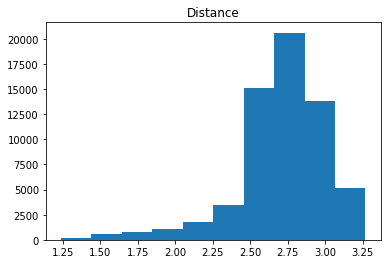

Beta mean: 0.01232431842438162
Gamma mean: 0.002077088013069226
R = mean(beta/gamma): 6.1654667371179634
R = median(beta/gamma): 6.397592650602411


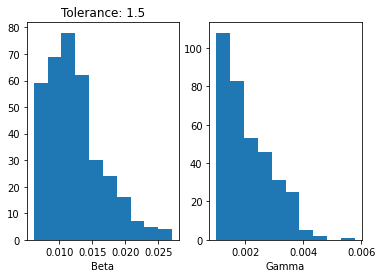

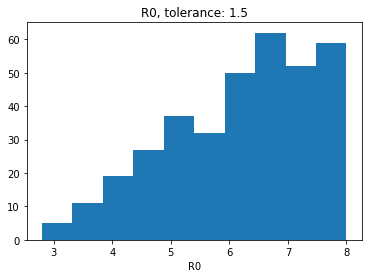

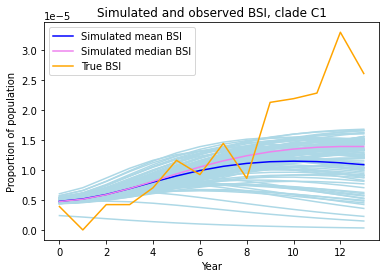

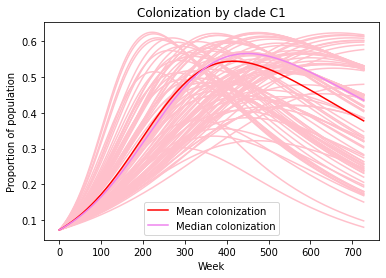

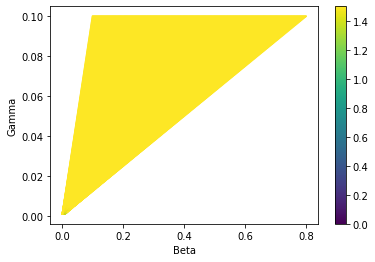

Results to visualize: res/sim_res/time shift/obs_NORM_C1_no_I0_2023-09-05_13-38-05/sim_params.txt
Year
2004    3.895481e-06
2005    3.949891e-10
2006    4.211914e-06
2007    4.214390e-06
2008    7.024155e-06
2009    1.158265e-05
2010    9.211101e-06
2011    1.440094e-05
2012    8.593462e-06
2013    2.123411e-05
2014    2.185052e-05
2015    2.278146e-05
2016    3.290818e-05
2017    2.603450e-05
Name: C1, dtype: float64


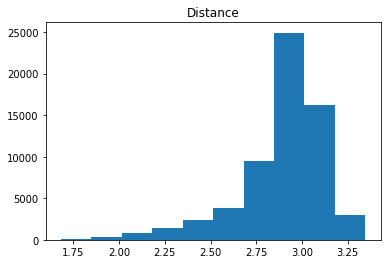

Beta mean: 0.039522004809588854
Gamma mean: 0.006322289156626506
R = mean(beta/gamma): 6.429964516246805
R = median(beta/gamma): 6.6365481325301205


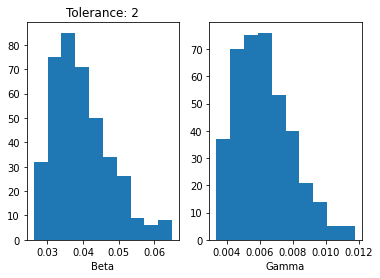

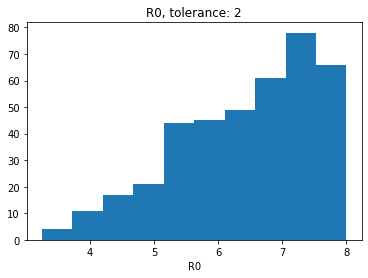

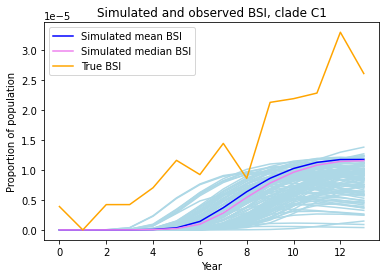

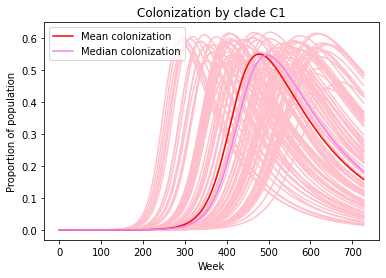

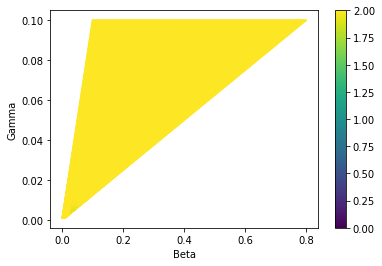

In [24]:
import grid_functions
importlib.reload(grid_functions)
from grid_functions import *


# NORM, clade C1:
visualize_results("res/sim_res/time shift/obs_NORM_C1_I0_2023-09-05_13-17-42", 1.5)

# NORM, clade C1, no I0:
visualize_results("res/sim_res/time shift/obs_NORM_C1_no_I0_2023-09-05_13-38-05", 2)

Results to visualize: res/sim_res/time shift/obs_NORM_B_I0_2023-09-05_12-38-26/sim_params.txt
Year
2004    0.000012
2005    0.000024
2006    0.000017
2007    0.000008
2008    0.000004
2009    0.000020
2010    0.000012
2011    0.000014
2012    0.000009
2013    0.000013
2014    0.000011
2015    0.000018
2016    0.000018
2017    0.000024
Name: B, dtype: float64


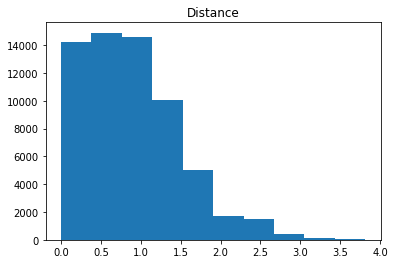

Beta mean: 0.09034715085165299
Gamma mean: 0.05888351915123179
R = mean(beta/gamma): 1.6954774474015466
R = median(beta/gamma): 1.5060333734939764


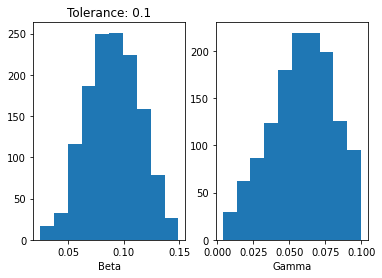

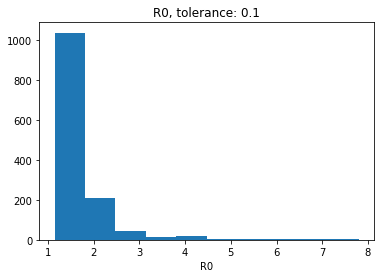

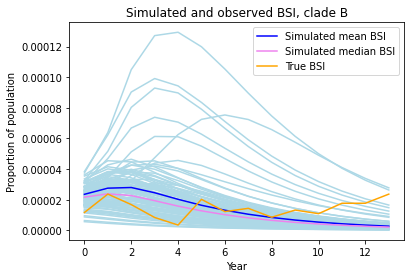

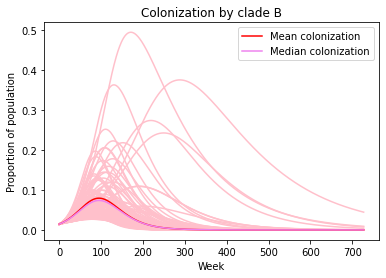

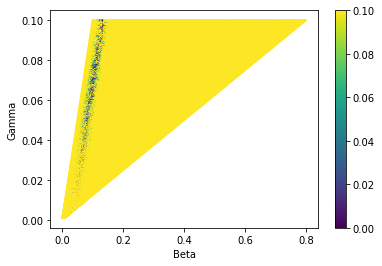

Results to visualize: res/sim_res/time shift/obs_NORM_B_no_I0_2023-09-05_12-58-17/sim_params.txt
Year
2004    0.000012
2005    0.000024
2006    0.000017
2007    0.000008
2008    0.000004
2009    0.000020
2010    0.000012
2011    0.000014
2012    0.000009
2013    0.000013
2014    0.000011
2015    0.000018
2016    0.000018
2017    0.000024
Name: B, dtype: float64


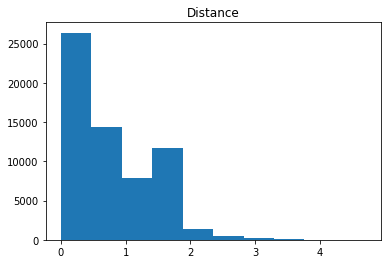

Beta mean: 0.33261905048045454
Gamma mean: 0.07107775313778836
R = mean(beta/gamma): 4.91228477854492
R = median(beta/gamma): 4.654623253012049


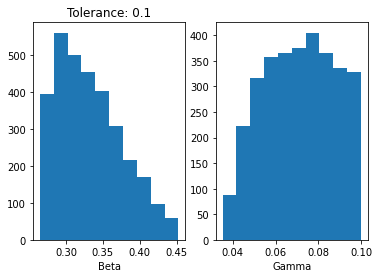

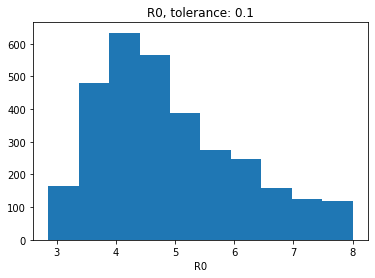

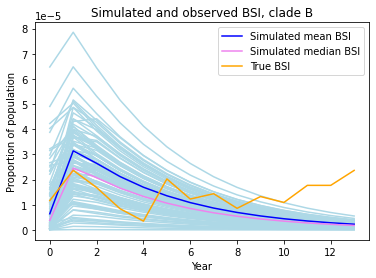

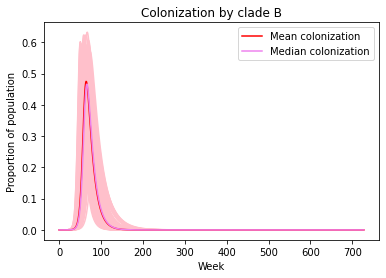

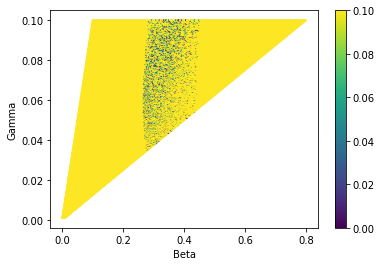

In [25]:
import grid_functions
importlib.reload(grid_functions)
from grid_functions import *


# NORM, clade B:
visualize_results("res/sim_res/time shift/obs_NORM_B_I0_2023-09-05_12-38-26", 0.1)

# NORM, clade B, no I0:
visualize_results("res/sim_res/time shift/obs_NORM_B_no_I0_2023-09-05_12-58-17", 0.1)